# Custom Datasets

## Import packages

In [2]:
import torch
import torch.nn as nn
import torch.optim as opt

In [102]:
from torch.utils.data import DataLoader, Dataset # for any data: tuen this into a torch.utils.data.DataLoader = iterable
from torchvision import datasets, transforms # specially for images so for other type go to the proper library

In [5]:
import torchvision
import torchinfo as ti

In [103]:
from typing import Tuple, Dict, List

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.model_selection import train_test_split

In [12]:
import requests

In [15]:
from pathlib import Path
import os
import zipfile

In [43]:
import random

In [53]:
import PIL

In [68]:
import numpy as np

In [6]:
print(torch.__version__)

2.12.0


## Device agnostic code

In [11]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"The device is: {device} and is {'available' if torch.backends.mps.is_built() else 'not available'}.")

The device is: mps and is available.


## Get the data

In [34]:
!wget "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"

--2026-06-09 15:48:39--  https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/pizza_steak_sushi.zip [following]
--2026-06-09 15:48:39--  https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/pizza_steak_sushi.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8002::154, 2606:50c0:8001::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15737296 (15M) [application/zip]
Saving to: ‘pizza_steak_sushi.zip’

pizza_steak_sushi.z 100%[===================>]  15.01M  4.49MB/s    in 3.5s    

2026-06-09 15:48:44 (4.26 MB/

In [35]:
data_path = Path("data")
image_path = data_path / "pizza_steak_suchi"

In [36]:
if image_path.exists():
    print("folder already exists")
else:
    print("Creating folder....")
    image_path.mkdir()

Creating folder....


In [38]:
# extract the zip file and put it in the correct directory
try:
    with zipfile.ZipFile("pizza_steak_sushi.zip", "r") as zip_file:
        zip_file.extractall(image_path) # path to where we want to extract data to
        print("File extracted ....")
except Exception as e:
    print("No zip file")
    print(e)
else:
    print("Removing zip file....")
    os.remove("pizza_steak_sushi.zip")

No zip file
[Errno 2] No such file or directory: 'pizza_steak_sushi.zip'


## Visualizing the data

In [39]:
def walk_through_dire(dirpath):
    for dirpath, dirnames, filenames in os.walk(dirpath):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.")

In [40]:
walk_through_dire(image_path)

There are 2 directories and 0 images in data/pizza_steak_suchi.
There are 3 directories and 0 images in data/pizza_steak_suchi/test.
There are 0 directories and 19 images in data/pizza_steak_suchi/test/steak.
There are 0 directories and 31 images in data/pizza_steak_suchi/test/sushi.
There are 0 directories and 25 images in data/pizza_steak_suchi/test/pizza.
There are 3 directories and 0 images in data/pizza_steak_suchi/train.
There are 0 directories and 75 images in data/pizza_steak_suchi/train/steak.
There are 0 directories and 72 images in data/pizza_steak_suchi/train/sushi.
There are 0 directories and 78 images in data/pizza_steak_suchi/train/pizza.


Using `PyTorch` or even `TensorFlow` the proper format of the folders is:

```text
train
    |__
        class_name
                |__ img1
                |__ img2
test
    |__
        class_name
                |__ img1
                |__ img2                

````

this is the way to do it (even with our own datasets for classification **WE SHOULD PUT THE DATA IN THIS FORMAT**)

In [42]:
# setting train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

In [44]:
SEED = 42

In [45]:
# visualizing our data
random.seed(SEED)

In [48]:
image_path_list = list(image_path.glob("*/*/*.jpg")) # * anything at this level starting at the image_path
image_path_list[:2]

[PosixPath('data/pizza_steak_suchi/test/steak/296375.jpg'),
 PosixPath('data/pizza_steak_suchi/test/steak/673127.jpg')]

In [62]:
random_image_path = random.choice(image_path_list)

In [59]:
image_class = random_image_path.parent.stem

In [86]:
with PIL.Image.open(random_image_path.as_posix()) as img:
    print(f"Random image path: {random_image_path.as_posix()}")
    print(f"Image class:{image_class.upper()}")
    print(f"Image height:{img.height}")
    print(f"Image width: {img.width}") # metadata from PIL

Random image path: data/pizza_steak_suchi/train/steak/3142045.jpg
Image class:STEAK
Image height:512
Image width: 512


In [70]:
img_as_array = np.asarray(img)

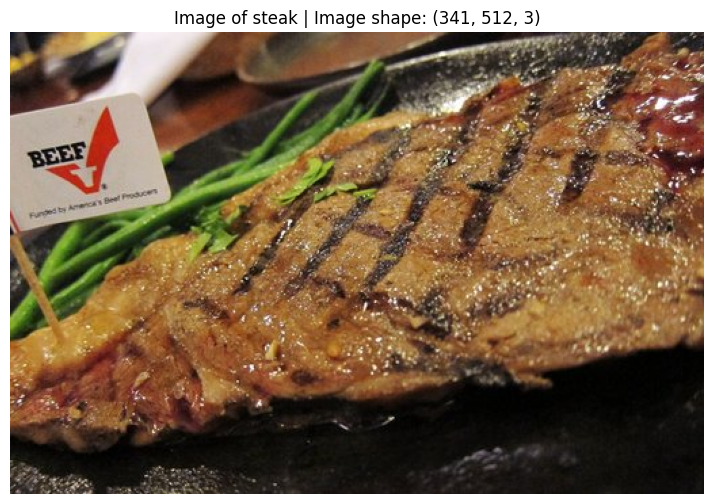

In [71]:
plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis(False)
plt.title(f"Image of {image_class} | Image shape: {img_as_array.shape}")
plt.show()

Careful that the shape here is `(HxZxC)` so color channel last whereas PyTorch is color channel first !!! so we need to deal with that later on

## Turn the data into tensors

The principle for ervery datasets to be loaded efficiently:
1. Turn the data into a `torch.utils.data.Dataset`
2. Turn the torch dataset into an iterable: `torch.utils.data.DataLoader`

In [73]:
# First we need to define the kind of transform we want to do: here tensors yes but also resizing and randomflipping
dataset_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [75]:
dataset_transform(img), dataset_transform(img).shape

(tensor([[[0.1882, 0.1686, 0.0902,  ..., 0.2039, 0.2196, 0.2118],
          [0.2039, 0.2000, 0.1294,  ..., 0.2471, 0.1882, 0.1569],
          [0.2039, 0.3137, 0.2902,  ..., 0.3843, 0.4000, 0.3098],
          ...,
          [0.3216, 0.3412, 0.3373,  ..., 0.0392, 0.0510, 0.0627],
          [0.2706, 0.3020, 0.3176,  ..., 0.0510, 0.0549, 0.0706],
          [0.2667, 0.2510, 0.2824,  ..., 0.0588, 0.0627, 0.0745]],
 
         [[0.1843, 0.1490, 0.0863,  ..., 0.1765, 0.2078, 0.1882],
          [0.1961, 0.1843, 0.1137,  ..., 0.2078, 0.1725, 0.1490],
          [0.1804, 0.2627, 0.2196,  ..., 0.2980, 0.3176, 0.2353],
          ...,
          [0.2784, 0.2941, 0.3020,  ..., 0.0353, 0.0471, 0.0588],
          [0.2392, 0.2667, 0.2784,  ..., 0.0471, 0.0510, 0.0667],
          [0.2314, 0.2235, 0.2431,  ..., 0.0549, 0.0588, 0.0706]],
 
         [[0.2000, 0.1529, 0.0980,  ..., 0.1569, 0.1961, 0.1765],
          [0.2118, 0.1765, 0.1137,  ..., 0.1843, 0.1686, 0.1529],
          [0.1843, 0.2078, 0.1647,  ...,

ok so here we see that the transfom has also adapted the shape (especially the color channel) to fit PyTorc

In [84]:
def plot_transformed_images(img_paths, transform, n = 3, seed = None):
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(img_paths, k = n)
    for image_path in random_image_paths:
        with PIL.Image.open(image_path) as file_:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(file_)
            ax[0].set_title(f"Originial \n size:{file_.size}")
            ax[0].axis(False)

            transformed_image = transform(file_).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \n size:{transformed_image.shape}")
            ax[1].axis(False)

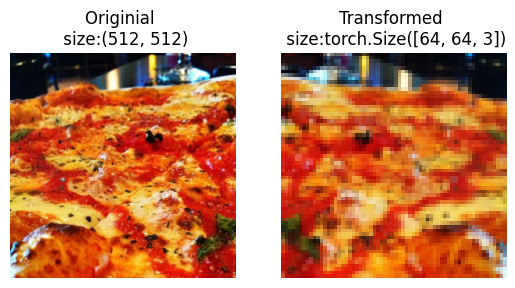

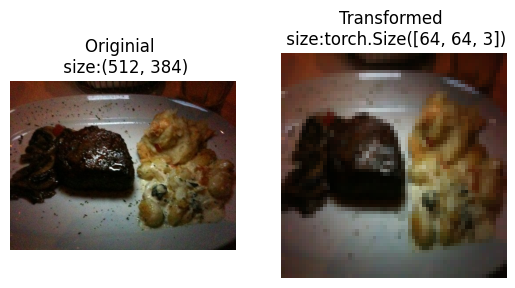

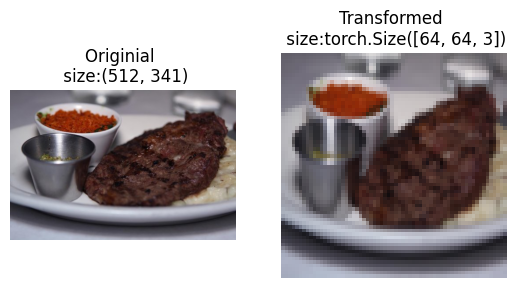

In [85]:
plot_transformed_images(image_path_list, dataset_transform, n = 3, seed = 42)

## Option 1: Loading the data using the `ImageFolder` class 

this assume that we have the classcial classification folder structure. 

So the first step is to create a `torch.utils.data.Datasets` then use the dataloader

In [87]:
train_data = datasets.ImageFolder(root=train_dir, transform=dataset_transform, target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=dataset_transform)

In [95]:
img, label = train_data[0][0], train_data[0][1]

In [96]:
os.cpu_count()

10

In [97]:
train_dataloader = DataLoader(dataset=train_data, 
                              batch_size=32, 
                              #num_workers=5,
                              shuffle=True, # good practice to avoid any patterns with data
                              )
test_dataloader = DataLoader(dataset=test_data, 
                              batch_size=32, 
                              #num_workers=5,
                              shuffle=False, # good practice to avoid any patterns with data
                              )

In [101]:
len(train_dataloader)

8

In [99]:
# check one batch
#next(iter(train_dataloader))

## Option 2: Custom Dataset

this is when we want to load files when our data is not in the proper format to load it with existing dataset function

In [105]:
train_data.classes # this is automatically accessible from the dataset

['pizza', 'steak', 'sushi']

In [106]:
target_directory = train_dir

In [108]:
class_names_found = sorted([entry.name for entry in os.scandir(target_directory)])
class_names_found

['pizza', 'steak', 'sushi']

In [109]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    classes = sorted([entry.name for entry in list(os.scandir(directory)) if entry.is_dir()])
    if not classes:
        raise FileNotFoundError(f"Could not find any classes in {directory}")
    
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}

    return classes, class_to_idx

In [111]:
find_classes(train_dir) # replicate the functionality of ImageFolder

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [114]:
img, label = train_data[0]
img, label # this what is being returned by the __getitem__ method in the class

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [121]:
# Create a custom dataset to replicate ImageFolder 
class ImageFolderCustom(Dataset):
    def __init__(self, targ_dir: str, transform=None):
        super().__init__()
        self.paths = list(Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)


    def load_image(self, index:int) -> PIL.Image:
        image_path = self.paths[index]
        return PIL.Image.open(image_path)
    

    def __len__(self) -> int:
        return len(self.paths)
    

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx


In [122]:
# Augment train data
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

# Don't augment test data, only reshape
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [127]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir, 
                                      transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir, 
                                     transform=test_transforms)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x123c65e00>,
 <__main__.ImageFolderCustom at 0x123c65ba0>)

In [128]:
train_dataloader_custom = DataLoader(dataset=train_data_custom, # use custom created train Dataset
                                     batch_size=1, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

test_dataloader_custom = DataLoader(dataset=test_data_custom, # use custom created test Dataset
                                    batch_size=1, 
                                    num_workers=0, 
                                    shuffle=False) # don't usually need to shuffle testing data

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x1274c1370>,
 <torch.utils.data.dataloader.DataLoader at 0x1274c1150>)

In [129]:
next(iter(train_dataloader_custom))

[tensor([[[[0.3569, 0.3686, 0.3765,  ..., 0.3098, 0.3137, 0.3216],
           [0.3647, 0.3725, 0.3765,  ..., 0.3176, 0.3255, 0.3333],
           [0.3647, 0.3725, 0.3765,  ..., 0.3216, 0.3294, 0.3412],
           ...,
           [0.6353, 0.6392, 0.6353,  ..., 0.3216, 0.3333, 0.3451],
           [0.6431, 0.6392, 0.6353,  ..., 0.3490, 0.3529, 0.3608],
           [0.6353, 0.6353, 0.6353,  ..., 0.3608, 0.3686, 0.3765]],
 
          [[0.6510, 0.6588, 0.6667,  ..., 0.5686, 0.5725, 0.5765],
           [0.6392, 0.6392, 0.6431,  ..., 0.5608, 0.5686, 0.5725],
           [0.6314, 0.6314, 0.6353,  ..., 0.5569, 0.5686, 0.5804],
           ...,
           [0.8471, 0.8510, 0.8549,  ..., 0.5412, 0.5490, 0.5608],
           [0.8549, 0.8549, 0.8510,  ..., 0.5647, 0.5686, 0.5765],
           [0.8471, 0.8471, 0.8471,  ..., 0.5765, 0.5843, 0.5882]],
 
          [[0.9765, 0.9843, 0.9882,  ..., 0.9176, 0.9176, 0.9216],
           [0.9725, 0.9765, 0.9765,  ..., 0.9098, 0.9176, 0.9216],
           [0.9647, 0.96